Load and register OpenUniverse2024 templates into sncosmo for subsequent use. Presumably,
these will need to be added when simulating as well if so wanted.

In [1]:
import os
import numpy as np
import pandas as pd
import sncosmo
import matplotlib.pyplot as plt

In [2]:
threshold = 0.01    # Extract phases and wavelengths beyond which the flux is lower than this times the peak

In [3]:
# Base dir for extracted data
bdir = '/Users/jnordin/data/openUniverse24/MODELS-1_TRANSIENT_SED'
# Fill this with data of individual models to load
modinfo = {}

In [4]:
# Get the OpenUniverse model for TDE AT2019qiz from the sncosmo registry
# (based on Hung et al. 2021 and Nicholl et al. 2020 data). This is described in arXiv:2501.05632
# from Zenodo record (Kessler 2025, CC-BY-4.0)
modinfo['tde-at2019qiz-ou'] = {
    'dir': 'NON1ASED.TDE-BBFIT',
    'fname': '2019qiz.sed.gz',
}

In [5]:
# [SLSN-I2016apd model SEDs are generated based on the HST spectra, Swift and ground-based photometry from Yan et al. 2017; Kanga et al, 2017, and Guillochon et al. 2017 (Open Supernova Database). The grey Blackbody fitting was done by Kaustav Das from Caltech.]
modinfo['slsn-i2016apd-ou'] = {
    'dir': 'NON1ASED.SLSN-I-BBFIT',
    'fname': '2016apd.sed.gz',
}

In [6]:
# There are many SNIax and PISN templates generated and available in OpenUniverse. We skip these now, but could
# in princple be used directly for training.
# Similarly the possis models for kilonovae

tde-at2019qiz-ou
/Users/jnordin/data/openUniverse24/MODELS-1_TRANSIENT_SED/NON1ASED.TDE-BBFIT/2019qiz.sed.gz
(84, 2301)
(59, 882)
slsn-i2016apd-ou
/Users/jnordin/data/openUniverse24/MODELS-1_TRANSIENT_SED/NON1ASED.SLSN-I-BBFIT/2016apd.sed.gz
(98, 2221)
(84, 1226)


<Figure size 640x480 with 0 Axes>

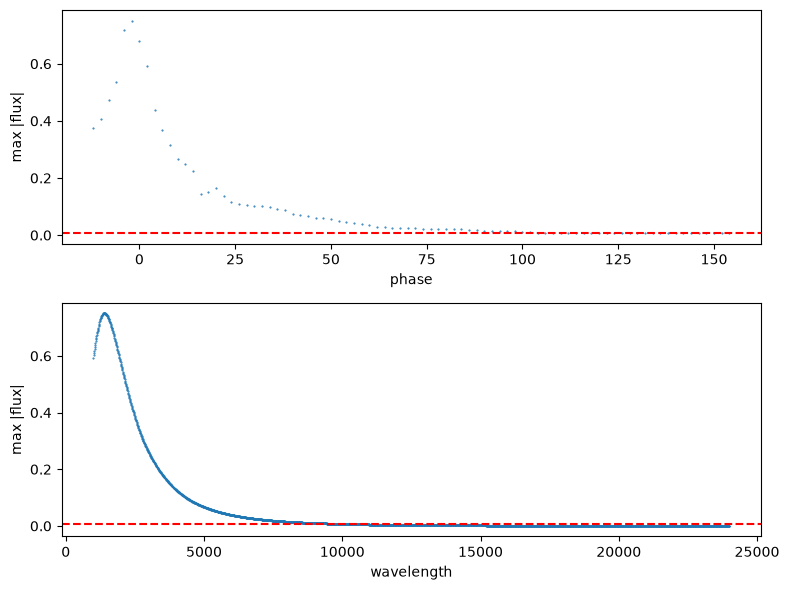

<Figure size 640x480 with 0 Axes>

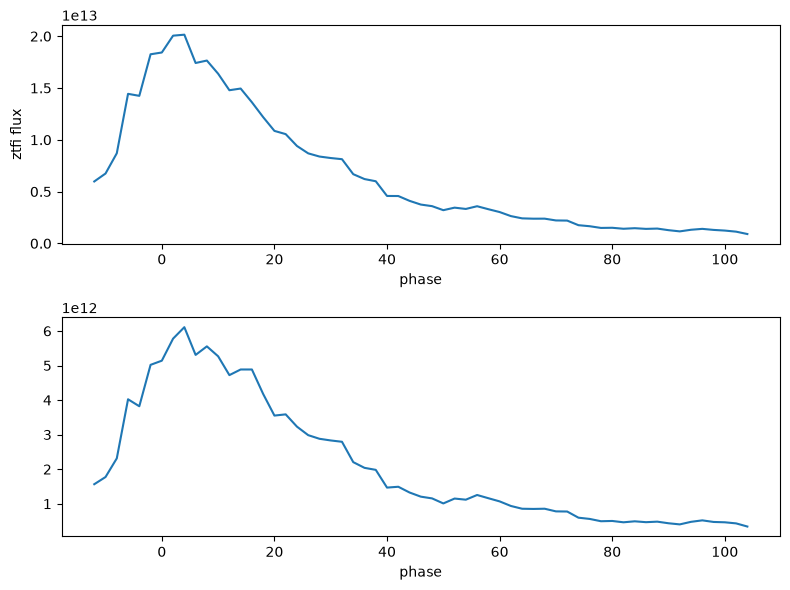

<Figure size 640x480 with 0 Axes>

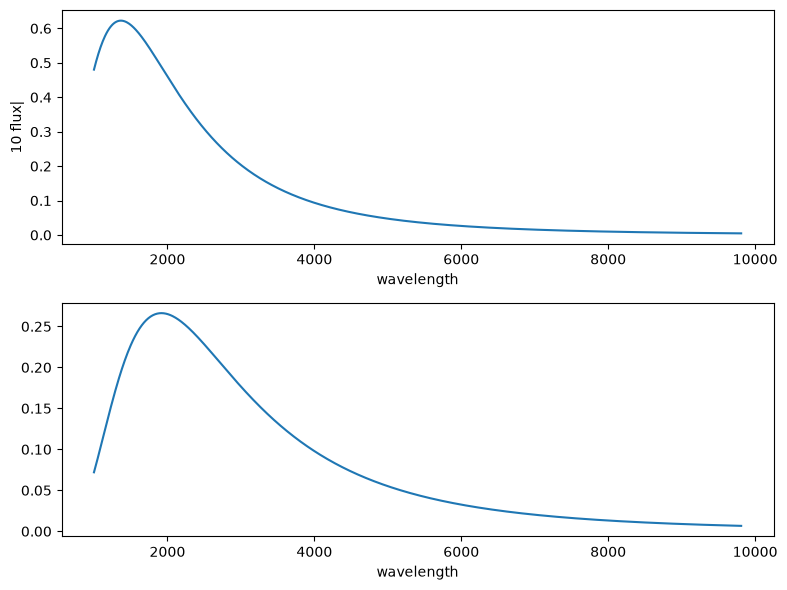

<Figure size 640x480 with 0 Axes>

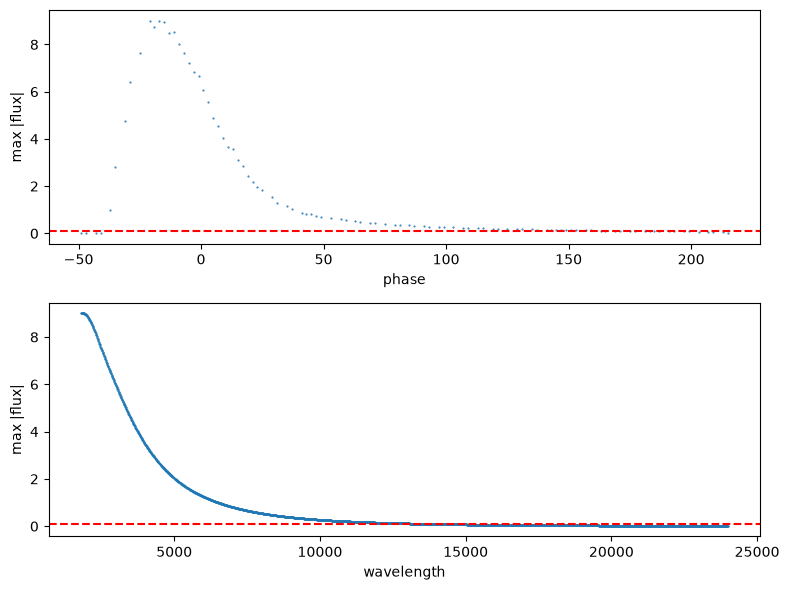

<Figure size 640x480 with 0 Axes>

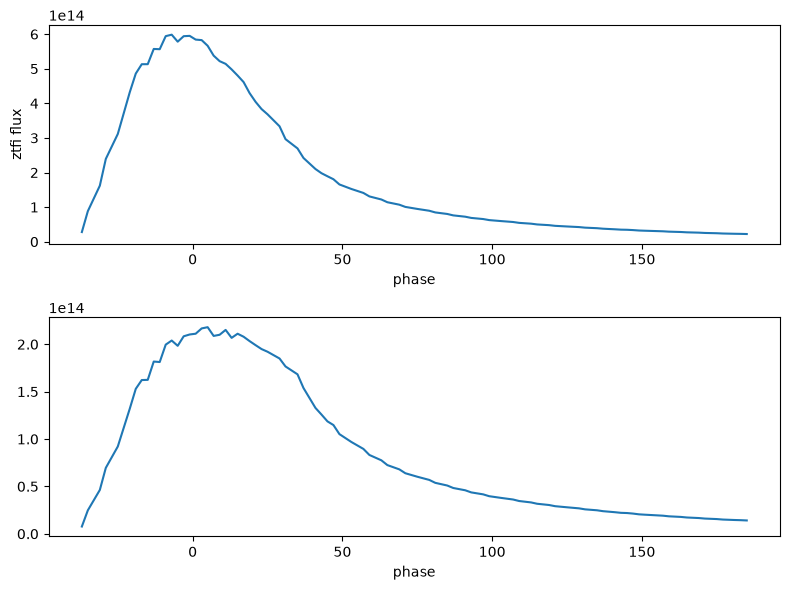

<Figure size 640x480 with 0 Axes>

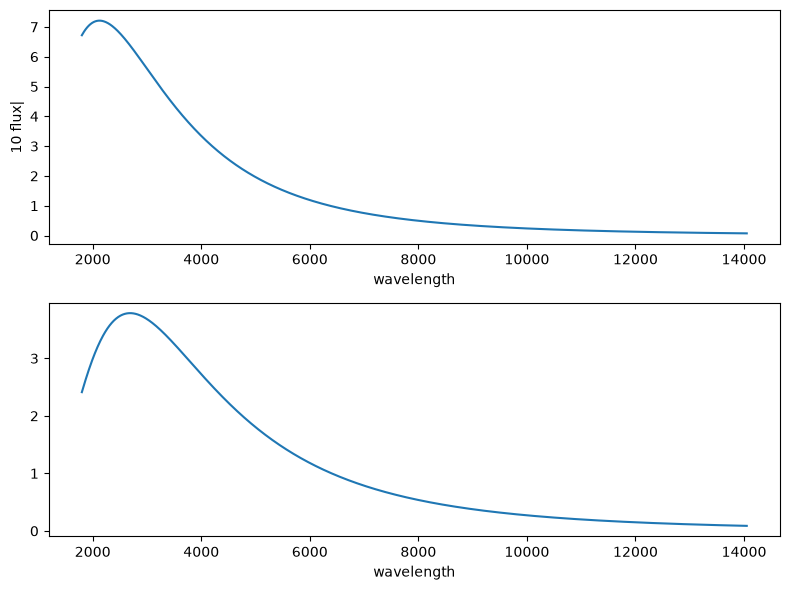

In [7]:
for name, tempdata in modinfo.items():
    print(name)
    path = os.path.join(bdir, tempdata['dir'], tempdata['fname'])
    print(path)
    df = pd.read_csv(path, 
        sep=r'\s+',           
        skiprows=2,           
        names=['phase', 'wavelength', 'flux']                     
        )
    # Base restructure
    pivoted = df.pivot(index='phase', columns='wavelength', values='flux')
    print(pivoted.shape)

    # Restrict to significant fluxes
    phase_max = pivoted.abs().max(axis=1)
    wave_max = pivoted.abs().max(axis=0)

    phase_mask = phase_max>phase_max.max()*threshold
    wave_mask = wave_max>wave_max.max()*threshold
    pivoted_cut = pivoted.loc[phase_mask, wave_mask]
    print(pivoted_cut.shape)

    # Final template
    phase = pivoted_cut.index.values      # 1-D array, sorted unique phases
    wave = pivoted_cut.columns.values     # 1-D array, sorted unique wavelengths
    flux = pivoted_cut.values             # 2-D array, shape (n_phase, n_wave)    

    # Plot base template
    plt.figure()

    fig, axes = plt.subplots(2, 1, figsize=(8, 6))
    axes[0].plot(pivoted.index, phase_max, '.', ms=1)
    axes[0].set_xlabel('phase'); axes[0].set_ylabel('max |flux|')
    axes[0].axhline(y=phase_max.max()*threshold, color='r', ls='--')
    
    axes[1].plot(pivoted.columns, wave_max, '.', ms=1)
    axes[1].set_xlabel('wavelength'); axes[1].set_ylabel('max |flux|')
    axes[1].axhline(y=wave_max.max()*threshold, color='r', ls='--')
    
    plt.tight_layout()

    # Create the sncosmo source
    source = sncosmo.TimeSeriesSource(phase, wave, flux, name=name, version='1.0')
    
    # Plot the source - phase
    plt.figure()
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))

    axes[0].plot(pivoted_cut.index, source.bandflux('ztfg', pivoted_cut.index) )
    axes[0].set_xlabel('phase'); axes[0].set_ylabel('ztfg flux')

    axes[1].plot(pivoted_cut.index, source.bandflux('ztfi', pivoted_cut.index) )
    axes[1].set_xlabel('phase'); axes[0].set_ylabel('ztfi flux')
    plt.tight_layout()

    # Plot the source - wavelenght
    plt.figure()
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))

    
    axes[0].plot(pivoted_cut.columns, source.flux(-5, pivoted_cut.columns) )
    axes[0].set_xlabel('wavelength'); axes[0].set_ylabel('-5 flux|')

    axes[1].plot(pivoted_cut.columns, source.flux(10, pivoted_cut.columns) )
    axes[1].set_xlabel('wavelength'); axes[0].set_ylabel('10 flux|')
    plt.tight_layout()

    # Register
    sncosmo.registry.register(source, name=name, force=True)



In [13]:
sncosmo.registry.retrieve??

Signature: sncosmo.registry.retrieve(data_class, name, version=None)
Source:   
def retrieve(data_class, name, version=None):
    """Retrieve a class instance from a registered identifier.

    Parameters
    ----------
    data_class : classobj
        The class of the object requested.
    name : str
        Identifier of the specific instance. `name` is case-independent,
        however, note the following: Internally, names are stored in lowercase.
        The retrieval is first tried assuming the requested name is also
        lowercase, then `name` is converted to lowercase. So it should be
        slightly faster to use lowercase names everywhere.
    version : str
        Sub-identifier. If `None`, default to highest or only version.

    Returns
    -------
    instance : data_class (or subclass thereof)

    Notes
    -----
    **Precedence** The following are tried in this order:

    1. If `name` is already an instance of `data_class`
       (rather than a string), it is im